In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib

import nltk
from nltk.corpus import stopwords
# from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [76]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /Users/gsus/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/gsus/nltk_data...
[nltk_data] Downloading package omw-1.4 to /Users/gsus/nltk_data...


True

In [77]:
df = pd.read_csv("../dataset/IMDB Dataset.csv")

In [78]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [79]:
df.shape

(50000, 2)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [81]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [82]:
df.duplicated().sum()

np.int64(418)

In [83]:
df = df.drop_duplicates()

In [84]:
df.shape

(49582, 2)

In [85]:
df.duplicated().sum()

np.int64(0)

In [86]:
df["sentiment"].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

In [87]:
df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

In [88]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [89]:
df["character_count"] = df["review"].apply(len)
df["word_count"] = df["review"].apply(lambda x: len(x.split()))
df["sentence_count"] = df["review"].apply(lambda x: x.count(".") + x.count("!") + x.count("?"))
df["exclamation_count"] = df["review"].apply(lambda x: x.count("!"))
df["question_count"] = df["review"].apply(lambda x: x.count("?"))
df["average_word_length"] = df["review"].apply(
    lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0
)

In [90]:
df.columns

Index(['review', 'sentiment', 'character_count', 'word_count',
       'sentence_count', 'exclamation_count', 'question_count',
       'average_word_length'],
      dtype='object')

In [91]:
df.head()

,review,sentiment,character_count,word_count,sentence_count,exclamation_count,question_count,average_word_length
0,One of the other reviewers has mentioned that ...,1,1761,307,26,0,0,4.739414
1,A wonderful little production. <br /><br />The...,1,998,162,7,1,0,5.166667
2,I thought this was a wonderful way to spend ti...,1,926,166,7,0,1,4.584337
3,Basically there's a family where a little boy ...,0,748,138,12,2,0,4.427536
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317,230,15,0,0,4.730435


In [92]:
# stop_words = set(stopwords.words("english"))
# stemmer = PorterStemmer()

stop_words = set(stopwords.words("english"))

custom_stopwords = {
    "movie", "film", "one", "show", "character", "story", "scene",
    "watch", "see", "seen", "look", "make", "made", "think", "know",
    "way", "time", "people", "actor", "act", "acting", "plot",
    "really", "even", "much", "many", "little", "also", "would",
    "could", "get", "got", "go", "went", "come", "came", "take",
    "thing", "something", "anything", "everything", "nothing",
    "well", "still", "seem", "seems", "use", "used", "first",
    "end", "begin", "part", "role", "director", "cast",
    "good", "bad"
}

stop_words = stop_words.union(custom_stopwords)

lemmatizer = WordNetLemmatizer()

In [93]:
# def clean_text(text):
#     text = text.lower()
#     text = re.sub(r"<.*?>", "", text)
#     text = re.sub(r"http\S+|www\S+", "", text)
#     text = re.sub(r"[^a-zA-Z]", " ", text)
#     words = text.split()
#     words = [word for word in words if word not in stop_words]
#     words = [stemmer.stem(word) for word in words]
#     return " ".join(words)

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words and len(word) > 2
    ]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [94]:
df["clean_review"] = df["review"].apply(clean_text)
df["clean_review_length"] = df["clean_review"].apply(lambda x: len(x.split()))
df[["review", "clean_review", "sentiment", "clean_review_length"]].head()

,review,clean_review,sentiment,clean_review_length
0,One of the other reviewers has mentioned that ...,reviewer mentioned watching episode hooked rig...,1,140
1,A wonderful little production. <br /><br />The...,wonderful production filming technique unassum...,1,75
2,I thought this was a wonderful way to spend ti...,thought wonderful spend hot summer weekend sit...,1,73
3,Basically there's a family where a little boy ...,basically family boy jake think zombie closet ...,0,52
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love money visually stunning mat...,1,91


In [95]:
df.describe()

,sentiment,character_count,word_count,sentence_count,exclamation_count,question_count,average_word_length,clean_review_length
count,49582.000000,49582.000000,49582.000000,49582.000000,49582.000000,49582.000000,49582.000000,49582.000000
mean,0.501876,1310.568230,231.350167,14.642471,0.978339,0.646807,4.640984,98.962930
std,0.500002,990.762238,171.542020,11.228651,2.915159,1.526309,0.340527,78.525443
min,0.000000,32.000000,4.000000,0.000000,0.000000,0.000000,1.239865,2.000000
25%,0.000000,699.000000,126.000000,8.000000,0.000000,0.000000,4.418247,50.000000
50%,1.000000,971.000000,173.000000,11.000000,0.000000,0.000000,4.627119,72.000000
75%,1.000000,1592.000000,281.000000,18.000000,1.000000,1.000000,4.847605,121.000000
max,1.000000,13704.000000,2470.000000,282.000000,282.000000,45.000000,12.290909,1297.000000


In [96]:
df[[
    "character_count",
    "word_count",
    "sentence_count",
    "exclamation_count",
    "question_count",
    "average_word_length",
    "clean_review_length"
]].describe()

,character_count,word_count,sentence_count,exclamation_count,question_count,average_word_length,clean_review_length
count,49582.000000,49582.000000,49582.000000,49582.000000,49582.000000,49582.000000,49582.000000
mean,1310.568230,231.350167,14.642471,0.978339,0.646807,4.640984,98.962930
std,990.762238,171.542020,11.228651,2.915159,1.526309,0.340527,78.525443
min,32.000000,4.000000,0.000000,0.000000,0.000000,1.239865,2.000000
25%,699.000000,126.000000,8.000000,0.000000,0.000000,4.418247,50.000000
50%,971.000000,173.000000,11.000000,0.000000,0.000000,4.627119,72.000000
75%,1592.000000,281.000000,18.000000,1.000000,1.000000,4.847605,121.000000
max,13704.000000,2470.000000,282.000000,282.000000,45.000000,12.290909,1297.000000


In [97]:
df.groupby("sentiment")[[
    "character_count",
    "word_count",
    "sentence_count",
    "exclamation_count",
    "question_count",
    "average_word_length",
    "clean_review_length"
]].mean()

,character_count,word_count,sentence_count,exclamation_count,question_count,average_word_length,clean_review_length
sentiment,,,,,,,
0,1294.739615,229.596607,15.303749,1.027452,0.908616,4.623474,96.281359
1,1326.278532,233.090620,13.986136,0.929593,0.386955,4.658363,101.624457


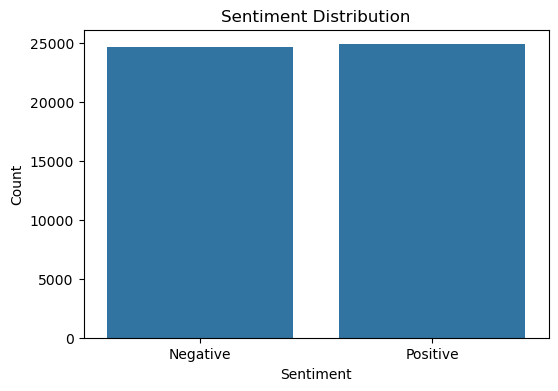

In [98]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sentiment")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.savefig("../outputs/sentiment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

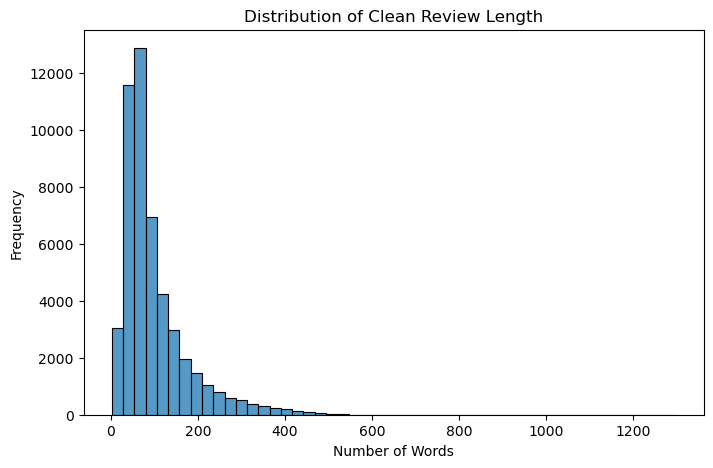

In [99]:
plt.figure(figsize=(8,5))
sns.histplot(df["clean_review_length"], bins=50)
plt.title("Distribution of Clean Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.savefig("../outputs/review_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

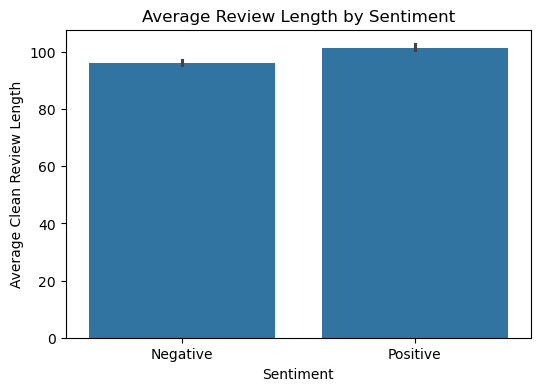

In [100]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="sentiment", y="clean_review_length")
plt.title("Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Clean Review Length")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.savefig("../outputs/average_review_length.png", dpi=300, bbox_inches="tight")
plt.show()

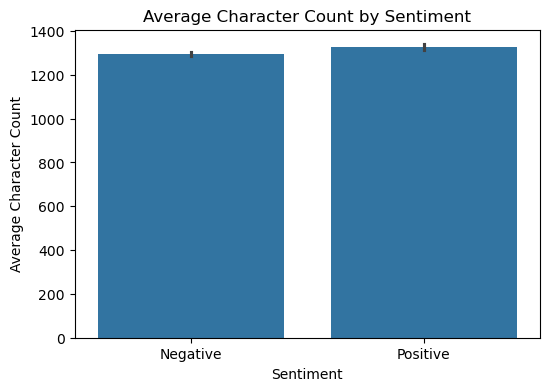

In [101]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="sentiment", y="character_count")
plt.title("Average Character Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Character Count")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.savefig("../outputs/character_count_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

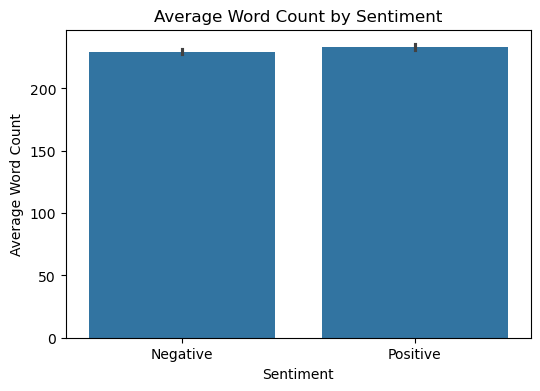

In [102]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="sentiment", y="word_count")
plt.title("Average Word Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Word Count")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.savefig("../outputs/word_count_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

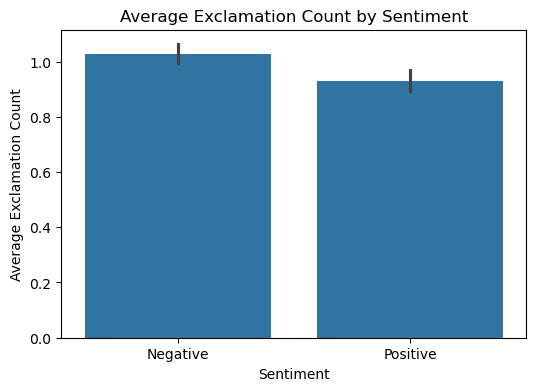

In [103]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="sentiment", y="exclamation_count")
plt.title("Average Exclamation Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Exclamation Count")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.savefig("../outputs/exclamation_count_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

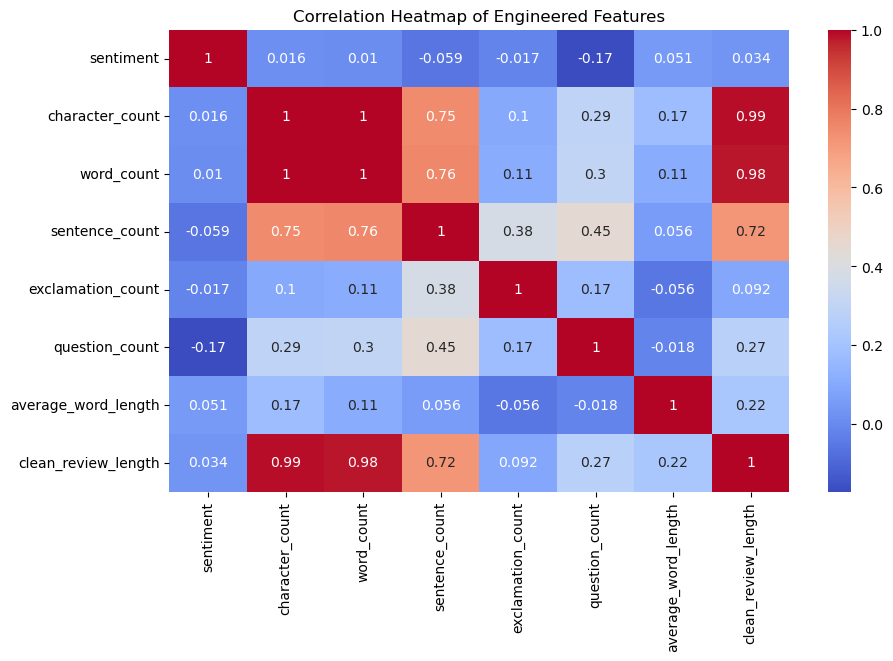

In [104]:
numeric_cols = [
    "sentiment",
    "character_count",
    "word_count",
    "sentence_count",
    "exclamation_count",
    "question_count",
    "average_word_length",
    "clean_review_length"
]

plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Engineered Features")
plt.savefig("../outputs/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

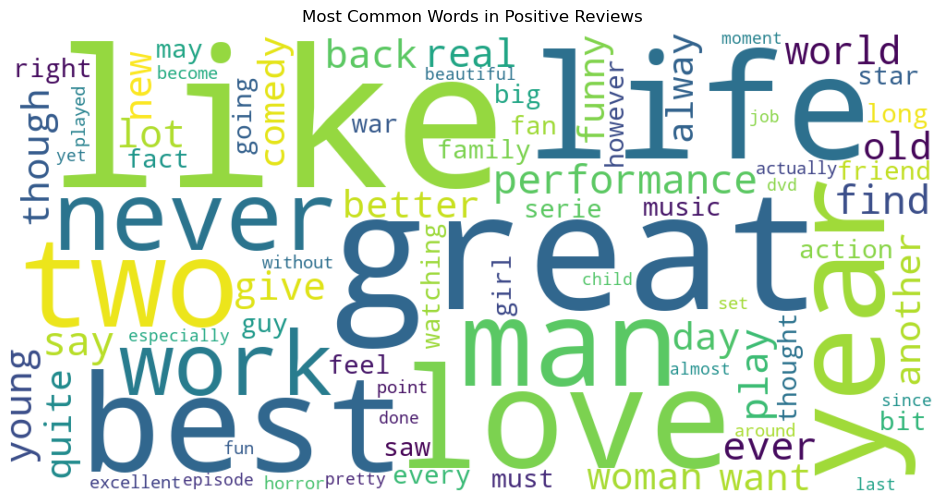

In [105]:
# positive_text = " ".join(df[df["sentiment"] == 1]["clean_review"])

# wordcloud = WordCloud(
#     width=800,
#     height=400,
#     background_color="white"
# ).generate(positive_text)

# plt.figure(figsize=(10,5))
# plt.imshow(wordcloud, interpolation="bilinear")
# plt.axis("off")
# plt.title("Most Common Words in Positive Reviews")
# plt.savefig("../outputs/positive_wordcloud.png", dpi=300, bbox_inches="tight")
# plt.show()

positive_text = " ".join(df[df["sentiment"] == 1]["clean_review"])

positive_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=80,
    collocations=False,
    stopwords=stop_words
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Positive Reviews")
plt.savefig("../outputs/positive_wordcloud.png", dpi=300, bbox_inches="tight")
plt.show()

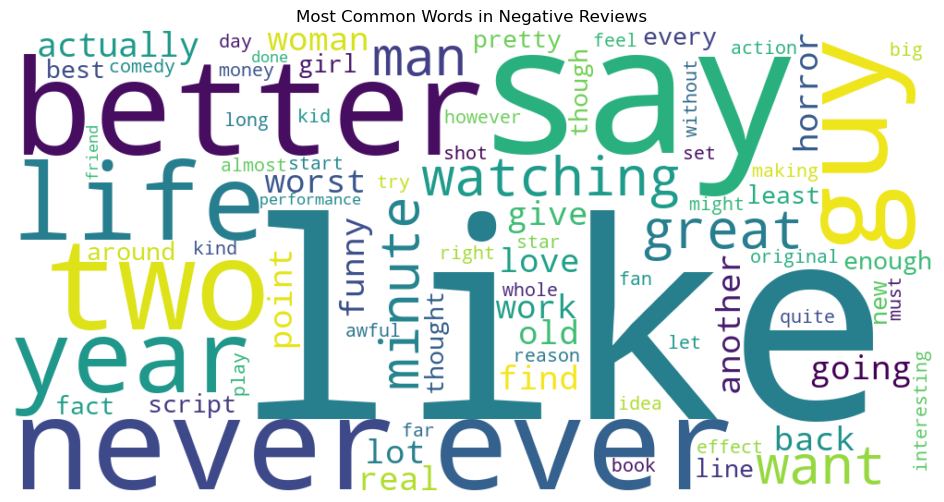

In [106]:
# negative_text = " ".join(df[df["sentiment"] == 0]["clean_review"])

# wordcloud = WordCloud(
#     width=800,
#     height=400,
#     background_color="white"
# ).generate(negative_text)

# plt.figure(figsize=(10,5))
# plt.imshow(wordcloud, interpolation="bilinear")
# plt.axis("off")
# plt.title("Most Common Words in Negative Reviews")
# plt.savefig("../outputs/negative_wordcloud.png", dpi=300, bbox_inches="tight")
# plt.show()

negative_text = " ".join(df[df["sentiment"] == 0]["clean_review"])

negative_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=80,
    collocations=False,
    stopwords=stop_words
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Negative Reviews")
plt.savefig("../outputs/negative_wordcloud.png", dpi=300, bbox_inches="tight")
plt.show()

In [107]:
X = df["clean_review"]
y = df["sentiment"]

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [109]:
X_train.shape, X_test.shape

((39665,), (9917,))

In [110]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [111]:
X_train_tfidf.shape

(39665, 5000)

In [112]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.8546939598668952
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      4940
           1       0.85      0.86      0.86      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



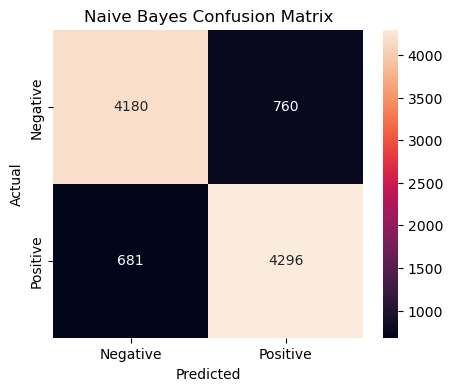

In [113]:
cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../outputs/naive_bayes_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [114]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8850458808107291
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4940
           1       0.88      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



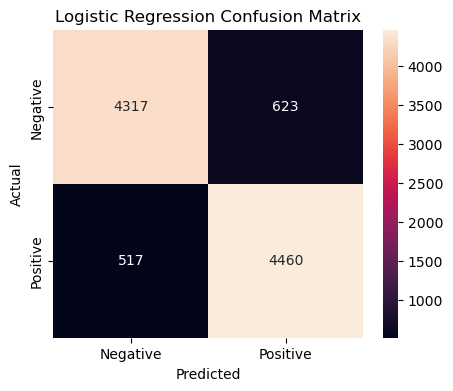

In [115]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../outputs/logistic_regression_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [116]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print("Linear SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

Linear SVM Accuracy: 0.8768780881314914
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      4940
           1       0.87      0.88      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



In [117]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_tfidf, y_train)

knn_pred = knn_model.predict(X_test_tfidf)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.7368155692245639
              precision    recall  f1-score   support

           0       0.78      0.65      0.71      4940
           1       0.70      0.82      0.76      4977

    accuracy                           0.74      9917
   macro avg       0.74      0.74      0.73      9917
weighted avg       0.74      0.74      0.73      9917



In [118]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "Linear SVM", "KNN"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, knn_pred)
    ]
})

results

,Model,Accuracy
0,Naive Bayes,0.854694
1,Logistic Regression,0.885046
2,Linear SVM,0.876878
3,KNN,0.736816


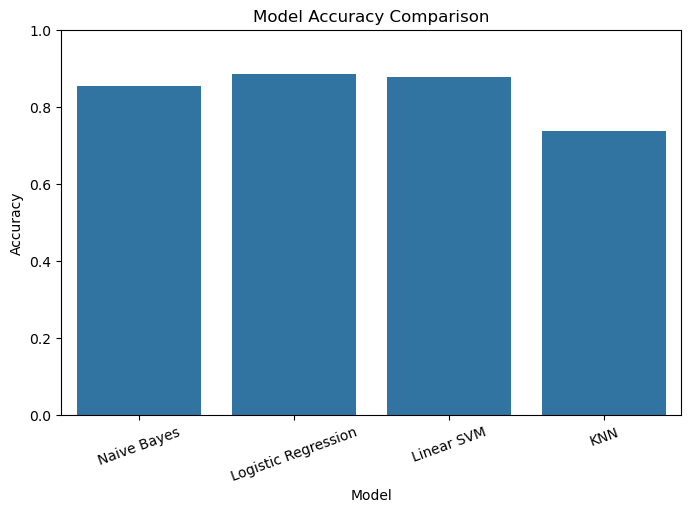

In [119]:
plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.savefig("../outputs/model_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [120]:
sentiment_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("model", LogisticRegression(max_iter=1000))
])

In [121]:
sentiment_pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [122]:
pipeline_pred = sentiment_pipeline.predict(X_test)

In [123]:
print("Pipeline Accuracy:", accuracy_score(y_test, pipeline_pred))
print(classification_report(y_test, pipeline_pred))

Pipeline Accuracy: 0.8850458808107291
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4940
           1       0.88      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [124]:
def predict_sentiment(review):
    cleaned_review = clean_text(review)
    prediction = sentiment_pipeline.predict([cleaned_review])[0]

    if prediction == 1:
        return "Positive Review"
    else:
        return "Negative Review"

In [125]:
predict_sentiment("The movie was amazing and the acting was excellent.")

'Positive Review'

In [126]:
predict_sentiment("The movie was boring, slow and completely disappointing.")

'Negative Review'

In [127]:
joblib.dump(sentiment_pipeline, "../models/movie_sentiment_pipeline.pkl")

['../models/movie_sentiment_pipeline.pkl']

In [128]:
loaded_model = joblib.load("../models/movie_sentiment_pipeline.pkl")

loaded_model.predict(["The movie was emotional and beautifully directed"])

array([1])

In [129]:
cluster_vectorizer = TfidfVectorizer(max_features=1000)
X_cluster = cluster_vectorizer.fit_transform(df["clean_review"])

In [130]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_cluster)

In [131]:
pd.crosstab(df["sentiment"], df["cluster"])

cluster,0,1
sentiment,,
0,7570,17128
1,19307,5577


In [132]:
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_cluster)

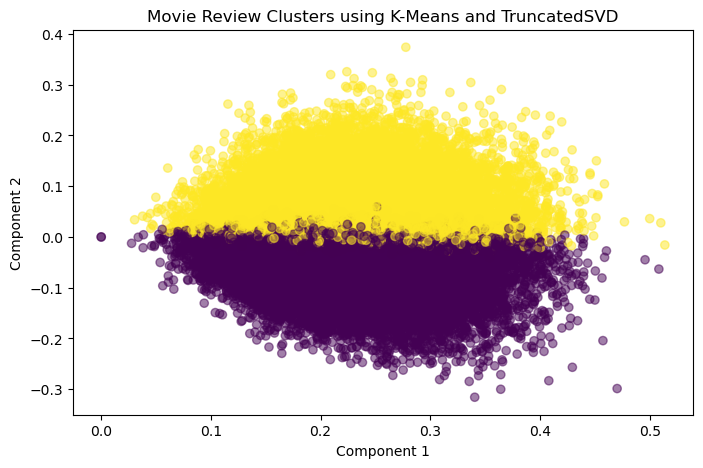

In [133]:
plt.figure(figsize=(8,5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df["cluster"], alpha=0.5)
plt.title("Movie Review Clusters using K-Means and TruncatedSVD")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.savefig("../outputs/cluster_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

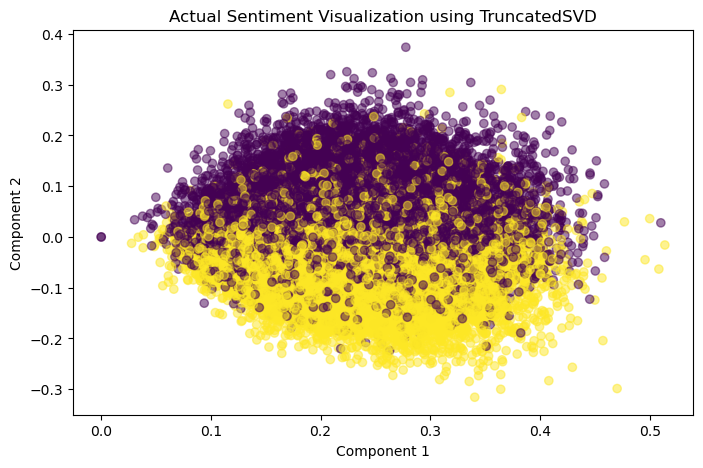

In [134]:
plt.figure(figsize=(8,5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df["sentiment"], alpha=0.5)
plt.title("Actual Sentiment Visualization using TruncatedSVD")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.savefig("../outputs/actual_sentiment_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

In [135]:
feature_names = sentiment_pipeline.named_steps["tfidf"].get_feature_names_out()
coefficients = sentiment_pipeline.named_steps["model"].coef_[0]

In [136]:
top_positive = coefficients.argsort()[-20:]

positive_words = pd.DataFrame({
    "Word": feature_names[top_positive],
    "Coefficient": coefficients[top_positive]
}).sort_values(by="Coefficient", ascending=False)

positive_words = positive_words.reset_index(drop=True)

positive_words

,Word,Coefficient
0,great,6.910364
1,excellent,6.732279
2,perfect,5.297792
3,best,5.116214
4,amazing,4.923616
5,wonderful,4.820156
6,favorite,4.590328
7,loved,4.483219
8,brilliant,4.393809
9,enjoyed,4.253003


In [137]:
top_negative = coefficients.argsort()[:20]

negative_words = pd.DataFrame({
    "Word": feature_names[top_negative],
    "Coefficient": coefficients[top_negative]
}).sort_values(by="Coefficient")

negative_words = negative_words.reset_index(drop=True)

negative_words

,Word,Coefficient
0,worst,-10.610180
1,awful,-8.260260
2,waste,-7.807195
3,boring,-6.566331
4,terrible,-6.143570
5,poor,-6.108977
6,horrible,-5.559963
7,worse,-5.540142
8,poorly,-5.216440
9,dull,-4.888094


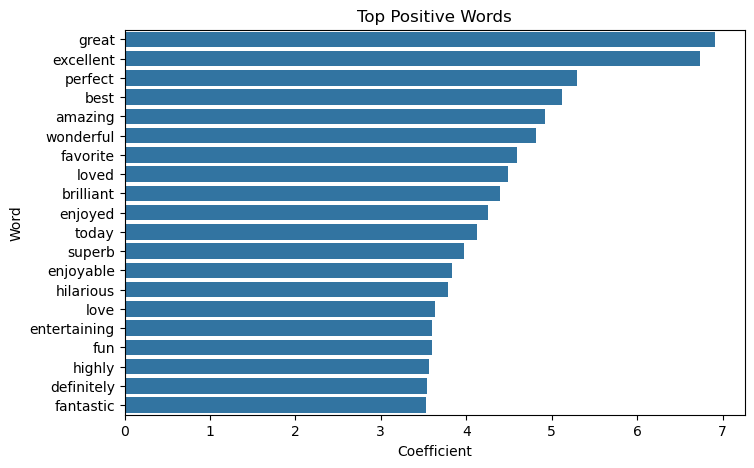

In [138]:
plt.figure(figsize=(8,5))
sns.barplot(data=positive_words, x="Coefficient", y="Word")
plt.title("Top Positive Words")
plt.savefig("../outputs/top_positive_words.png", dpi=300, bbox_inches="tight")
plt.show()

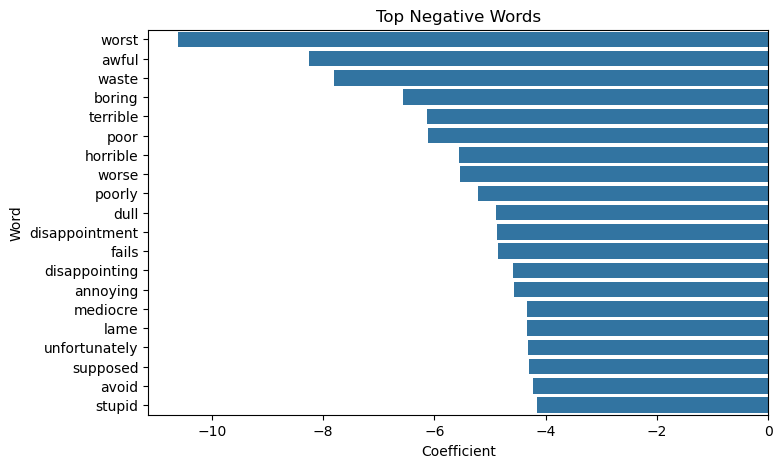

In [139]:
plt.figure(figsize=(8,5))
sns.barplot(data=negative_words, x="Coefficient", y="Word")
plt.title("Top Negative Words")
plt.savefig("../outputs/top_negative_words.png", dpi=300, bbox_inches="tight")
plt.show()

In [140]:
df.to_csv("../outputs/enhanced_imdb_reviews.csv", index=False)

## Conclusion

This project performed movie review sentiment classification using NLP and machine learning. The original IMDb dataset contained only two columns: review and sentiment. Additional features such as character count, word count, sentence count, exclamation count, question count, average word length, clean review, and clean review length were created using feature engineering.

The review text was cleaned by removing HTML tags, punctuation, numbers, stopwords, and unnecessary words. Lemmatization was used instead of stemming to keep words readable. TF-IDF vectorization converted the cleaned text into numerical features.

Supervised machine learning models such as Naive Bayes, Logistic Regression, Linear SVM, and KNN were trained and evaluated. The models were compared using accuracy, precision, recall, F1-score, and confusion matrix. K-Means clustering was also applied for unsupervised learning, and TruncatedSVD was used to visualize review clusters.

The project demonstrates a complete data science workflow using Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, and NLTK.